# 04 — Model Evaluation

Load the best saved model and evaluate it on the held-out test set.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import numpy as np
import config
from tensorflow.keras.models import load_model
from src.preprocessing import load_and_preprocess
from src.tokenizer_utils import load_tokenizer, texts_to_padded_sequences
from src.evaluate import evaluate_model, plot_confusion_matrix, plot_roc_curve
from sklearn.model_selection import train_test_split

c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.10) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## 1. Load model & tokenizer

In [2]:
model     = load_model(config.MODEL_PATH)
tokenizer = load_tokenizer()
print("Model loaded:", config.MODEL_PATH)

2026-06-30 03:09:15 | INFO | tokenizer_utils | Tokenizer loaded ← c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\models\tokenizer.pkl
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\u2190' in position 64: character maps to <undefined>
Call stack:
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\suppa\AppData\Roaming\Python\Python310\sit

Model loaded: c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\models\bilstm_spam_model.h5


## 2. Reconstruct test set

In [3]:
df = load_and_preprocess()
X = df['cleaned_text'].values; y = df['label'].values
_, X_test_raw, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_test = texts_to_padded_sequences(tokenizer, X_test_raw.tolist())
print("Test size:", len(y_test), "| Spam:", y_test.sum(), "| Ham:", (y_test==0).sum())

2026-06-30 03:09:15 | INFO | preprocessing | Loading dataset from c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\dataset\spam.csv
INFO:preprocessing:Loading dataset from c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\dataset\spam.csv
2026-06-30 03:09:15 | INFO | preprocessing | Loaded 5169 rows  |  spam=653  ham=4516
INFO:preprocessing:Loaded 5169 rows  |  spam=653  ham=4516
2026-06-30 03:09:15 | INFO | preprocessing | Encoding labels …
INFO:preprocessing:Encoding labels …
2026-06-30 03:09:15 | INFO | preprocessing | Cleaning text (this may take a moment) …
INFO:preprocessing:Cleaning text (this may take a moment) …
2026-06-30 03:09:15 | INFO | preprocessing | Preprocessing complete.
INFO:preprocessing:Preprocessing complete.


Test size: 1034 | Spam: 131 | Ham: 903


## 3. Metrics

In [4]:
results = evaluate_model(model, X_test, y_test)

2026-06-30 03:09:17 | INFO | evaluate | Accuracy : 0.9865
INFO:evaluate:Accuracy : 0.9865
2026-06-30 03:09:17 | INFO | evaluate | ROC-AUC  : 0.9920
INFO:evaluate:ROC-AUC  : 0.9920
2026-06-30 03:09:17 | INFO | evaluate | 
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       903
        spam       0.99      0.90      0.94       131

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034

INFO:evaluate:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       903
        spam       0.99      0.90      0.94       131

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034

2026-06-30 03:09:17 | INFO | evaluate | Evaluation results saved → c:\Users\suppa\Downloads\Spam_Email_Detecti

## 4. Confusion matrix

2026-06-30 03:09:17 | INFO | evaluate | Confusion matrix saved → c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\saved_plots\confusion_matrix.png
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 63: character maps to <undefined>
Call stack:
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\suppa\AppData\Roaming\Python\Py

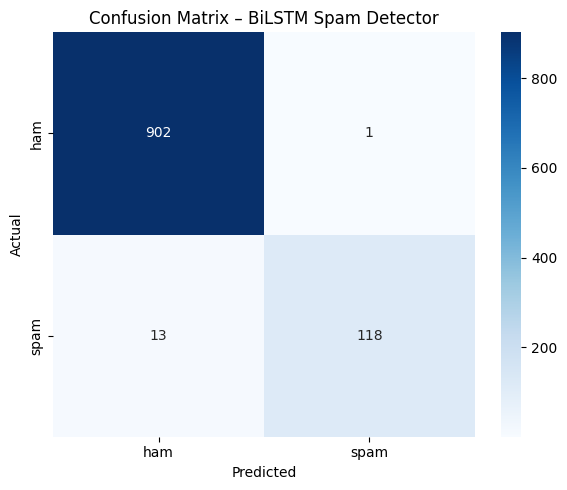

In [5]:
plot_confusion_matrix(y_test, np.array(results['y_pred']))

## 5. ROC curve

2026-06-30 03:09:17 | INFO | evaluate | ROC curve saved → c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\saved_plots\roc_curve.png
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 56: character maps to <undefined>
Call stack:
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\suppa\AppData\Roaming\Python\Python310\site-p

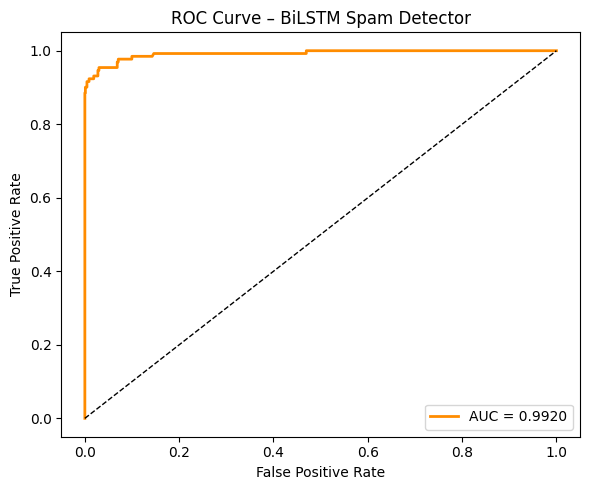

In [6]:
plot_roc_curve(y_test, np.array(results['y_prob']))

## 6. Live predictions

In [7]:
from src.predictor import SpamPredictor
pred = SpamPredictor()
test_msgs = [
    "WINNER!! You have been selected to receive a £900 prize reward! Call 09061701461 now.",
    "Hey, can we reschedule our meeting to Thursday morning?",
    "FREE iPhone! Click here to claim your prize before midnight.",
    "Please remember to submit your timesheet by end of day Friday.",
]
for msg in test_msgs:
    r = pred.predict(msg)
    icon = '🔴' if r['is_spam'] else '🟢'
    print(f"{icon} {r['label'].upper():4s} ({r['confidence']:.2%})  |  {msg[:60]}")

2026-06-30 03:09:17 | INFO | predictor | Loading model ← c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\models\bilstm_spam_model.h5
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\u2190' in position 55: character maps to <undefined>
Call stack:
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\suppa\AppData\Roaming\Python\Python310\site-

🔴 SPAM (99.81%)  |  WINNER!! You have been selected to receive a £900 prize rewa
🟢 HAM  (99.97%)  |  Hey, can we reschedule our meeting to Thursday morning?
🔴 SPAM (99.60%)  |  FREE iPhone! Click here to claim your prize before midnight.
🟢 HAM  (99.82%)  |  Please remember to submit your timesheet by end of day Frida
